In [1]:
# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.datasets import fetch_california_housing  # Real-world dataset
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


In [4]:
class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    
config = Config()

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"file:///{os.path.abspath(config.EXPERIMENT_DIR)}")
experiment_name = "Medical_Insurance_cost"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location=('file:///c:\\Users\\user\\ALEX.AI\\SAIR_Jr\\1_Regression\\Regression Capstone '
 'Projects\\Awab.poject\\experiments/845697618217024994'), creation_time=1773243583588, experiment_id='845697618217024994', last_update_time=1773243583588, lifecycle_stage='active', name='Medical_Insurance_cost', tags={}>

In [26]:
# Load the dataset
df = pd.read_csv("C:/Users/user/Downloads/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
# Basic statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [28]:
# check for missing values
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [40]:
# Split into features and target- y is the target variable we want to predict 
X= df.drop("charges", axis=1)
y = df["charges"]

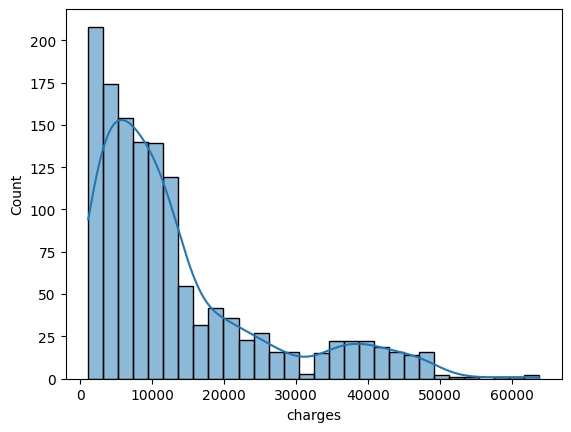

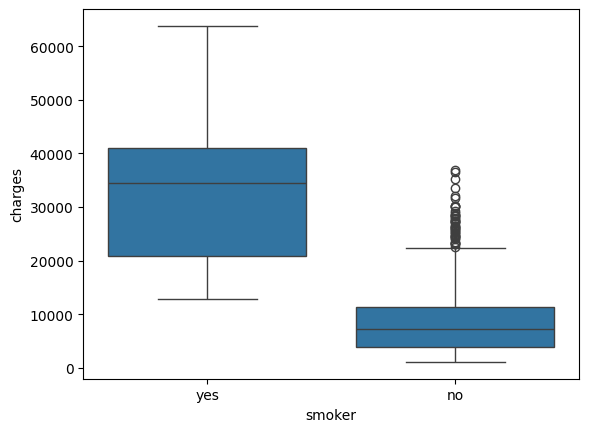

In [41]:
# Visualize the distribution of the target variable , charges and smoker
sns.histplot(df["charges"], kde = True)
plt.show()

sns.boxplot(x ="smoker" , y = "charges", data = df)
plt.show()


In [59]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    """Robust Feature Engineering for Medical Insurance (Flexible & Safe)"""

    def __init__(self):
        self.feature_names = []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_eng = X.copy()


        # the main columns
        age = X_eng["age"]
        bmi = X_eng["bmi"]
        children = X_eng["children"]

        # encode the smoker feature only to be included without errors
        if X_eng["smoker"].dtype == "object":
            smoker = X_eng["smoker"].map({"yes": 1, "no": 0})
        else:
            smoker = X_eng["smoker"]

        # Feature Engineering
        X_eng["age_bmi_interaction"] = age * bmi
        X_eng["smoker_bmi"] = smoker * bmi
        X_eng["smoker_age"] = smoker * age

        X_eng["bmi_per_child"] = bmi / (children + 1)

        X_eng["is_obese"] = (bmi > 30).astype(int)
        X_eng["is_senior"] = (age > 50).astype(int)
        X_eng["has_children"] = (children > 0).astype(int)

        X_eng["age_squared"] = age ** 2
        X_eng["age_group"] = (age // 10) * 10

        self.feature_names = X_eng.columns.tolist()

        return X_eng

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    def get_feature_names(self):
        return self.feature_names

engineer = AdvancedFeatureEngineer()
X_engineered = engineer.fit_transform(X)

print("✅ FEATURE ENGINEERING COMPLETE!")
print(f"• Total features: {X_engineered.shape[1]}")  
print(engineer.get_feature_names())

X_engineered.info()

✅ FEATURE ENGINEERING COMPLETE!
• Total features: 15
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'age_bmi_interaction', 'smoker_bmi', 'smoker_age', 'bmi_per_child', 'is_obese', 'is_senior', 'has_children', 'age_squared', 'age_group']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1338 non-null   int64  
 1   sex                  1338 non-null   object 
 2   bmi                  1338 non-null   float64
 3   children             1338 non-null   int64  
 4   smoker               1338 non-null   object 
 5   region               1338 non-null   object 
 6   age_bmi_interaction  1338 non-null   float64
 7   smoker_bmi           1338 non-null   float64
 8   smoker_age           1338 non-null   int64  
 9   bmi_per_child        1338 non-null   float64
 10  is_obese             1338 non-null   int64  

In [68]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
X_engineered = AdvancedFeatureEngineer().fit_transform(X)

categorical_cols = X_engineered.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_engineered.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ]
)

X_prepared = preprocessor.fit_transform(X_engineered)


In [69]:
# NEW: Outlier Handler for Robust Models
class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handle outliers using IQR method - More robust than simple scaling"""
    
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
    
    def fit(self, X, y=None):
        X = np.array(X)
        self.lower_bounds_ = []
        self.upper_bounds_ = []
        
        # Calculate IQR bounds for each feature
        for i in range(X.shape[1]):
            Q1 = np.percentile(X[:, i], 25)  # 25th percentile
            Q3 = np.percentile(X[:, i], 75)  # 75th percentile  
            IQR = Q3 - Q1  # Interquartile Range
            self.lower_bounds_.append(Q1 - self.factor * IQR)
            self.upper_bounds_.append(Q3 + self.factor * IQR)
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        # Clip values to IQR bounds
        for i in range(X.shape[1]):
            lower = self.lower_bounds_[i]
            upper = self.upper_bounds_[i]
            X_transformed[:, i] = np.clip(X_transformed[:, i], lower, upper)
        
        return X_transformed

In [75]:

# Create comprehensive preprocessing pipeline
preprocessor = Pipeline([
    ("feature_engineering", AdvancedFeatureEngineer()),

    ("encoding", ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop='first'), categorical_cols)
        ]
    )),

    ("outlier", OutlierHandler()), 
    ("scaler", RobustScaler())
])

# Apply preprocessing pipeline
print(" Applying preprocessing pipeline...")
X_processed = preprocessor.fit_transform(X, y)

print("ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f" Processed data shape: {X_processed.shape}")
print(f" All feature names: {preprocessor.named_steps['feature_engineering'].get_feature_names()}")

 Applying preprocessing pipeline...
ADVANCED PREPROCESSING PIPELINE BUILT!
 Processed data shape: (1338, 17)
 All feature names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'age_bmi_interaction', 'smoker_bmi', 'smoker_age', 'bmi_per_child', 'is_obese', 'is_senior', 'has_children', 'age_squared', 'age_group']


In [76]:
# Improved data splitting with validation set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)


print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)") 
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")

📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 856 samples (model learning)
• Validation: 214 samples (hyperparameter tuning)
• Test: 268 samples (final evaluation - NEVER TOUCHED until end)


In [77]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):


In [78]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Comprehensive model evaluation with MLflow tracking"""
    
    # Start MLflow run for experiment tracking
    with mlflow.start_run(run_name=model_name):
        # Train model with timing
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Predictions on both sets
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # Calculate comprehensive metrics
        metrics = {
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
            'train_r2': r2_score(y_train, y_train_pred),
            'val_r2': r2_score(y_val, y_val_pred),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'val_mae': mean_absolute_error(y_val, y_val_pred),
            'training_time': training_time,
            'overfitting_gap': r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred)
        }
        
        # AUTOMATIC TRACKING with MLflow
        mlflow.log_params(model.get_params())  # Log hyperparameters
        mlflow.log_metrics({k: v for k, v in metrics.items() if k != 'training_time'})
        mlflow.sklearn.log_model(model, "model")  # Save model artifact
        
        # Cross-validation for robust performance estimate
        cv_scores = cross_val_score(model, X_train, y_train, 
                                  cv=config.CV_FOLDS, scoring='r2', n_jobs=config.N_JOBS)
        metrics['cv_r2_mean'] = cv_scores.mean()
        metrics['cv_r2_std'] = cv_scores.std()
        
        mlflow.log_metrics({
            'cv_r2_mean': metrics['cv_r2_mean'],
            'cv_r2_std': metrics['cv_r2_std']
        })
        
        return metrics, model

print("🚀 STARTING ADVANCED MODEL EVALUATION...")
print("Each model is being trained, evaluated, and tracked in MLflow")

results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(
        model, X_train, X_val, y_train, y_val, name
    )
    results[name] = metrics
    trained_models[name] = trained_model
    
    # Progress reporting
    overfitting_indicator = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} "
          f"{overfitting_indicator}")

print(f"\n📈 All models trained and tracked in MLflow!")
print(f"💡 Check MLflow UI: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")

🚀 STARTING ADVANCED MODEL EVALUATION...
Each model is being trained, evaluated, and tracked in MLflow

🔧 Training Linear Regression...


2026/03/22 17:12:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:14:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:14:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Linear Regression    | Val R²: 0.1550 | CV R²: 0.0776 ± 0.0584 ✅

🔧 Training Ridge Regression...


2026/03/22 17:14:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:15:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:15:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Ridge Regression     | Val R²: 0.1553 | CV R²: 0.0823 ± 0.0589 ✅

🔧 Training Lasso Regression...


...

✅ Gradient Boosting    | Val R²: 0.0854 | CV R²: -0.0370 ± 0.0977 ⚠️

🔧 Training Support Vector Regression...


2026/03/22 17:16:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:16:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:16:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Support Vector Regression | Val R²: -0.1207 | CV R²: -0.0956 ± 0.0388 ✅

🔧 Training Voting Ensemble...


2026/03/22 17:16:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:17:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:17:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Voting Ensemble      | Val R²: 0.1103 | CV R²: 0.0288 ± 0.0808 ⚠️

📈 All models trained and tracked in MLflow!
💡 Check MLflow UI: mlflow ui --backend-store-uri experiments


📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.154978,11611.122769,9233.546719,-0.034425,0.077629
1,Ridge Regression,0.155331,11608.694806,9243.129972,-0.035024,0.082277
2,Lasso Regression,0.155140,11610.009713,9234.071526,-0.034595,0.078273
3,ElasticNet,0.130424,11778.603932,9328.778915,-0.031825,0.083209
4,Random Forest,-0.002416,12646.320985,9702.068793,0.844515,-0.078804
5,Gradient Boosting,0.085429,12079.500026,9457.790515,0.361475,-0.036962
6,Support Vector Regression,-0.120660,13371.407386,8832.674879,0.028718,-0.095581
7,Voting Ensemble,0.110338,11913.865558,9467.663094,0.430832,0.028833


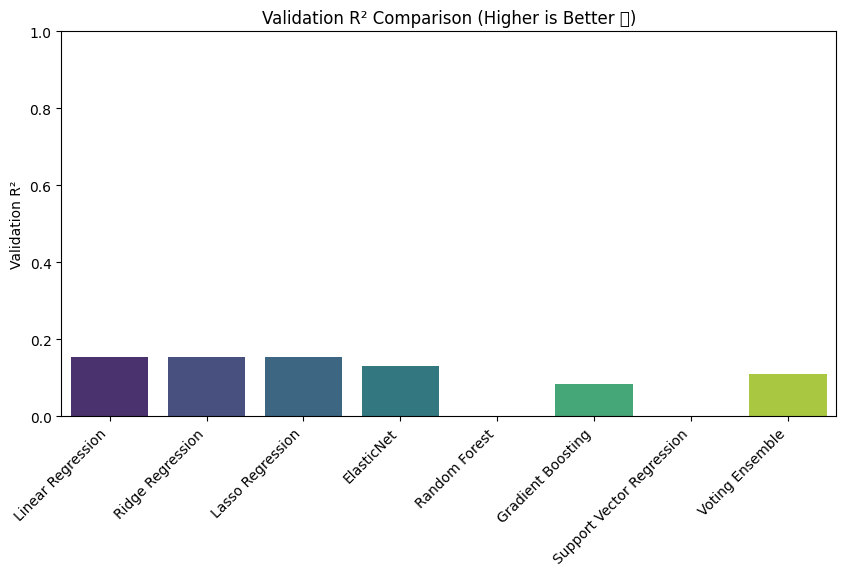

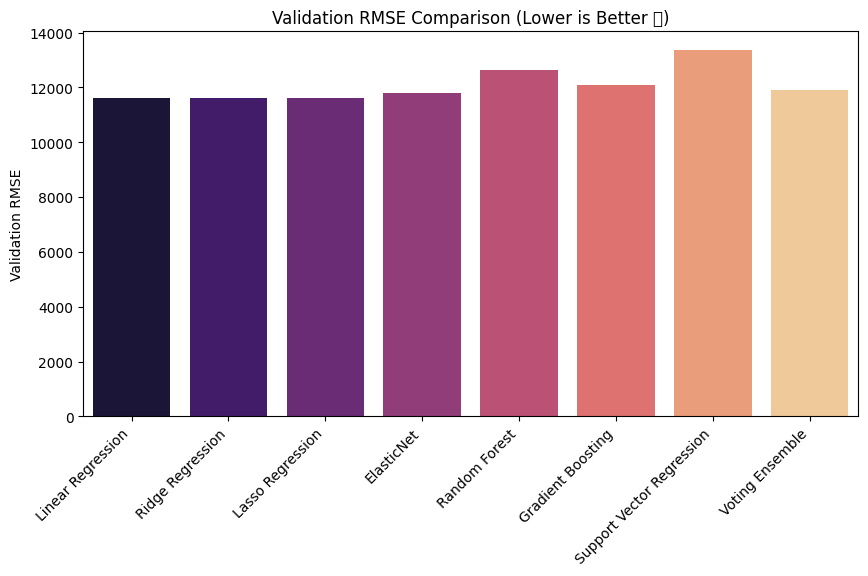

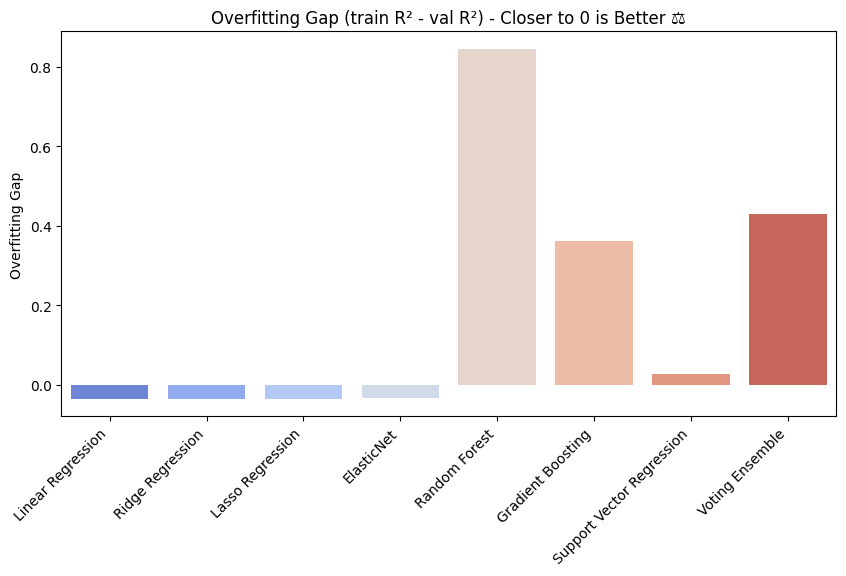

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert results dict to DataFrame
# ===========================
metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("📊 Model comparison table:")
display(metrics_df)

# ===========================
# 2️⃣ Plot Validation R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.show()

# ===========================
# 3️⃣ Plot Validation RMSE (Lower is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.show()

# ===========================
# 4️⃣ Plot Overfitting Gap (Closer to 0 is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.show()


📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Ridge Regression           0.1553  0.0823 ± 0.0589   ✅ -0.0350      0.06
Lasso Regression           0.1551  0.0783 ± 0.0582   ✅ -0.0346      0.03
Linear Regression          0.1550  0.0776 ± 0.0584   ✅ -0.0344      0.22
ElasticNet                 0.1304  0.0832 ± 0.0260   ✅ -0.0318      0.01
Voting Ensemble            0.1103  0.0288 ± 0.0808  ⚠️  0.4308      1.27
Gradient Boosting          0.0854 -0.0370 ± 0.0977  ⚠️  0.3615      0.50
Random Forest             -0.0024 -0.0788 ± 0.1173  ⚠️  0.8445      0.81
Support Vector Regression -0.1207 -0.0956 ± 0.0388   ✅  0.0287      0.23


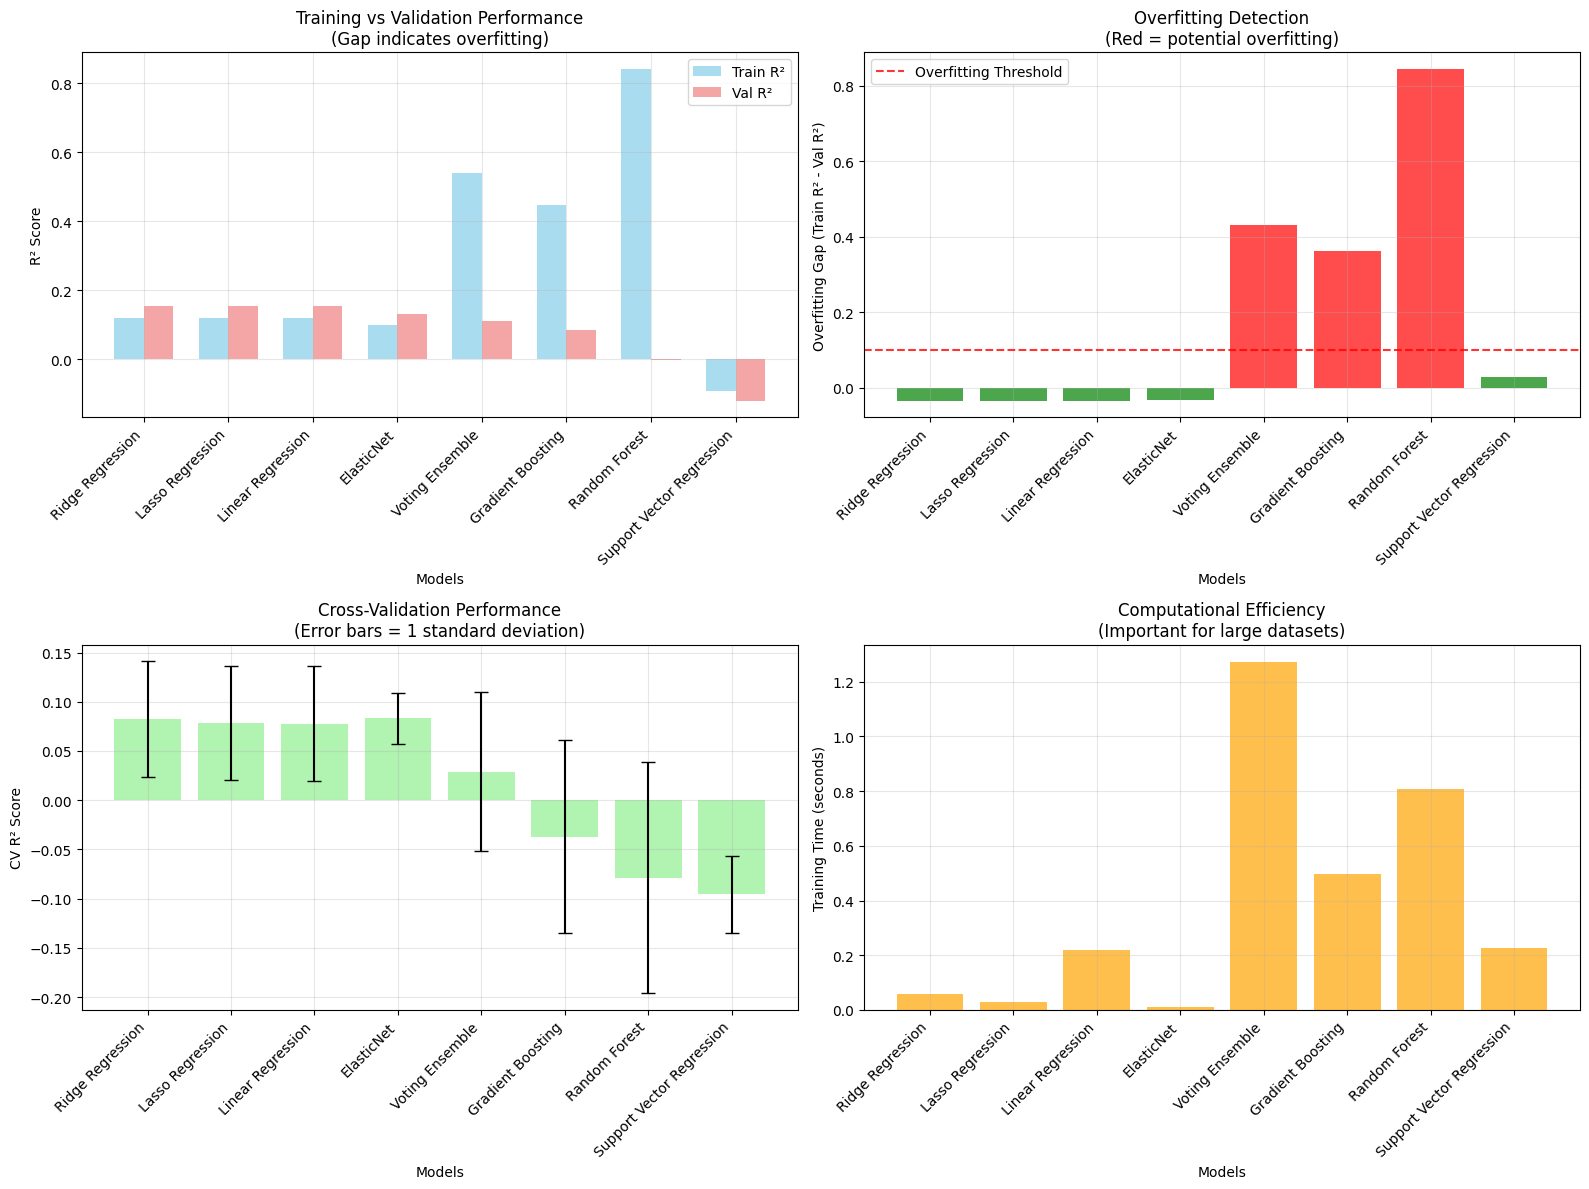


🎯 BEST MODEL SELECTED: Ridge Regression
📊 Validation R²: 0.1553
🔍 CV R²: 0.0823 ± 0.0589

💡 INTERPRETATION GUIDE:
• Good: High R², small train-val gap, stable CV, reasonable training time
• Overfitting: Large gap between train and validation performance
• Unstable: Large CV standard deviation
• Best choice: Balances performance, stability, and efficiency


In [80]:
# 📈 CELL 7: Advanced Model Comparison Visualization
print("📈 ADVANCED MODEL COMPARISON")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison
models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Overfitting Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")

print("\n💡 INTERPRETATION GUIDE:")
print("• Good: High R², small train-val gap, stable CV, reasonable training time")
print("• Overfitting: Large gap between train and validation performance") 
print("• Unstable: Large CV standard deviation")
print("• Best choice: Balances performance, stability, and efficiency")

In [81]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],  # Number of trees
        'max_depth': [None, 10, 20, 30],       # Tree depth
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'min_samples_leaf': [1, 2, 4],         # Minimum samples per leaf
        'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splits
    },
    
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4, 5, 6],             # Maximum depth per tree
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'subsample': [0.8, 0.9, 1.0]           # Fraction of samples for fitting
    },
    
    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],  # Regularization strength
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']  # Algorithm
    },
    
    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0, 10.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
} 

In [82]:

# Perform hyperparameter optimization
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression', 'Voting Ensemble']:
    print(f"\n🔧 Tuning {model_name}...")
    
    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # Use RandomizedSearchCV for efficient optimization
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=20,  # Try 20 random combinations (efficient!)
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=config.N_JOBS,
            random_state=config.RANDOM_STATE,
            verbose=1
        )
        
        # Perform the search
        search.fit(X_train, y_train)
        
        # Store results
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }
        
        # Log to MLflow
        mlflow.log_params(search.best_params_)
        mlflow.log_metric('best_cv_score', search.best_score_)
        mlflow.sklearn.log_model(search.best_estimator_, "tuned_model")
        
        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/03/22 17:27:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:27:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:27:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Random Forest        | Best CV R²: 0.0395
   Best parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/03/22 17:27:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:28:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:28:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Gradient Boosting    | Best CV R²: 0.0591
   Best parameters found: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 4, 'learning_rate': 0.01}

🔧 Tuning Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/03/22 17:28:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:28:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:28:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Ridge Regression     | Best CV R²: 0.0879
   Best parameters found: {'solver': 'saga', 'alpha': 100.0}

🔧 Tuning Voting Ensemble...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/03/22 17:28:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 17:29:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 17:29:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Voting Ensemble      | Best CV R²: 0.0563
   Best parameters found: {'ridge__alpha': 1.0, 'rf__n_estimators': 100, 'rf__max_depth': 10, 'gb__n_estimators': 50, 'gb__learning_rate': 0.05}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.039485
1,Gradient Boosting,0.059095
2,Ridge Regression,0.087916
3,Voting Ensemble,0.056315


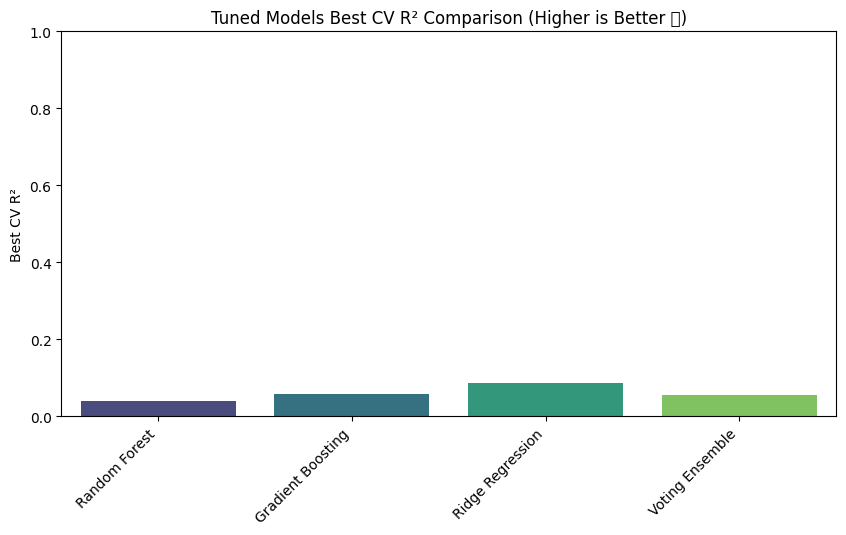

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10,5))
sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0,1)
plt.show()


Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest           -0.0024     0.0945 📈   0.0969
Gradient Boosting        0.0854     0.0816 📉  -0.0039
Ridge Regression         0.1553     0.1501 📉  -0.0052
Voting Ensemble          0.1103     0.1164 📈   0.0060


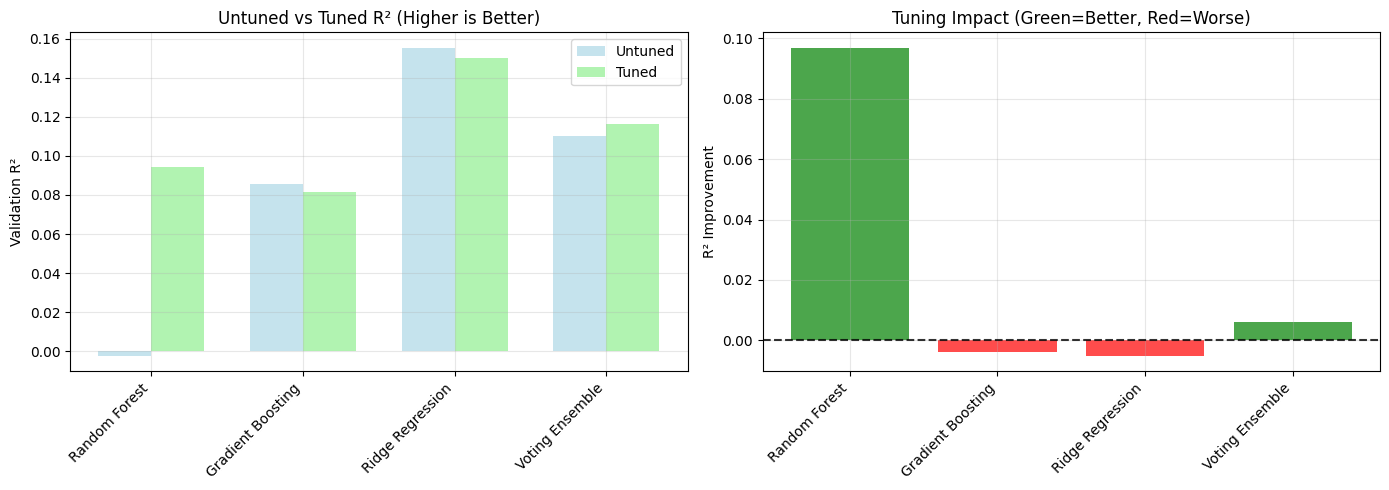


🏆 BEST TUNED MODEL: Ridge Regression
📊 Validation R²: 0.1501
📈 Improvement over untuned: +-0.0052


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  # vs untuned
    
    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")


In [85]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_tuned_model = tuned_models[best_model_name] # add this line 

# Predict on test set
y_test_pred = best_tuned_model.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")


📊 Test R²: 0.1468
📊 Test RMSE: 11508.7952
📊 Test MAE: 9134.0044


# 🚀 Model Deployment Preparation
Now that we have selected the best tuned model and confirmed it generalizes well on the validation (and test) data, we can prepare it for deployment.

# This involves several important steps:
1️⃣ Identify the best model based on validation performance.

2️⃣ Version the model and save both the trained model and preprocessing pipeline.

3️⃣ Create a comprehensive model card containing metadata, performance metrics, data information, model configuration, preprocessing steps, and deployment instructions.

4️⃣ Save deployment requirements to ensure reproducibility in production.

These steps ensure that the model is production-ready and can be deployed (e.g., via Streamlit) in a consistent, versioned, and well-documented manner.


In [86]:
import os
import json
import joblib
from datetime import datetime
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ===========================
# 0️⃣ Prepare feature names
# ===========================
# Works for both DataFrame and NumPy array
try:
    feature_names_all = list(X.columns)
except AttributeError:
    feature_names_all = [f"feature_{i}" for i in range(X.shape[1])]

# ===========================
# 1️⃣ Identify best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

# ===========================
# 2️⃣ Evaluate on Test Set
# ===========================
y_test_pred = best_tuned_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Test Set Performance:")
print(f"R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# ===========================
# 4️⃣ Create model card
# ===========================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'California Housing',
    'target': 'House Price ($M)',
    
    'performance': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'train_r2': float(results[best_model_name]['train_r2']),
        'val_r2': float(tuned_results[best_model_name]['val_r2']),
        'cv_r2_mean': float(results[best_model_name]['cv_r2_mean']),
        'cv_r2_std': float(results[best_model_name]['cv_r2_std']),
    },
    
    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': X_test.shape[1],
        'feature_names': feature_names_all,
    },
    
    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params()) 
            if hasattr(best_tuned_model, 'get_params') else {},
    },
    
    'preprocessing': {
        'steps': [
            'AdvancedFeatureEngineering (6 new features)',
            'OutlierHandling (IQR method)',
            'RobustScaler (outlier-resistant scaling)',
        ],
        'outlier_factor': 1.5,
    },
    
    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors in production',
            'Retrain quarterly with new data',
            'Alert if RMSE exceeds $0.50M',
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

# ===========================
# 6️⃣ Summary
# ===========================
print("\n💾 DEPLOYMENT PACKAGE READY")
print(f"Location: {model_save_dir}")


🏆 BEST TUNED MODEL: Ridge Regression
📊 Validation R²: 0.1501
📈 Improvement over untuned: +-0.0052

📊 Test Set Performance:
R²: 0.1468 | RMSE: 11508.7952 | MAE: 9134.0044
✅ Model saved: models\v1_20260322_225911\best_model.pkl
✅ Preprocessor saved: models\v1_20260322_225911\preprocessor.pkl
✅ Model card saved: models\v1_20260322_225911\model_card.json
✅ Deployment requirements saved: models\v1_20260322_225911\requirements.json

💾 DEPLOYMENT PACKAGE READY
Location: models\v1_20260322_225911


In [91]:
# bulding an interactive UI for model inference

import gradio as gr
import pandas as pd
import joblib
import glob
import os

# Load model & preprocessor

# Get latest model folder
model_folders = glob.glob("models/v1_*")

if not model_folders:
    raise Exception("❌ No model folders found")

MODEL_DIR = max(model_folders, key=os.path.getmtime)

model_path = os.path.join(MODEL_DIR, "best_model.pkl")
preprocessor_path = os.path.join(MODEL_DIR, "preprocessor.pkl")

#  Load
model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

# =========================
# Prediction function
# =========================
def predict(age, sex, bmi, children, smoker, region):
    
    input_data = pd.DataFrame({
        "age": [age],
        "sex": [sex],
        "bmi": [bmi],
        "children": [children],
        "smoker": [smoker],
        "region": [region]
    })
    
    processed = preprocessor.transform(input_data)
    prediction = model.predict(processed)
    
    return f"💰 Estimated Insurance Cost: ${prediction[0]:,.2f}"

# =========================
# UI
# =========================
interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(18, 65, label="Age"),
        gr.Radio(["male", "female"], label="Sex"),
        gr.Slider(10.0, 50.0, label="BMI"),
        gr.Slider(0, 5, step=1, label="Children"),
        gr.Radio(["yes", "no"], label="Smoker"),
        gr.Dropdown(["northeast", "northwest", "southeast", "southwest"], label="Region")
    ],
    outputs="text",
    title="💰 Medical Insurance Cost Predictor",
    description="Enter details to predict insurance charges"
)

# =========================
# Run app
# =========================
if __name__ == "__main__":
    interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Using existing dataset file at: .gradio\flagged\dataset1.csv
